In [63]:
import numpy as np
from ordered_set import OrderedSet
from copy import deepcopy

In [64]:
arr = np.loadtxt(
    "tools/sm_associativity_counts.csv",
    delimiter=",",
    skiprows=1,
    usecols=range(1, 133),
    dtype=int,
)

In [65]:
SMs_with_same_invocation_count = [OrderedSet() for _ in range(np.max(arr) + 1)]

for i in range(arr.shape[0]):
    SMs_with_same_invocation_count[arr[i, i]].add(i)

In [66]:
for i in range(len(SMs_with_same_invocation_count)):
    if len(SMs_with_same_invocation_count[i]) > 0:
        print(f"{i} (len={len(SMs_with_same_invocation_count[i])}): {SMs_with_same_invocation_count[i]}")

195 (len=2): OrderedSet([130, 131])
200 (len=6): OrderedSet([124, 125, 126, 127, 128, 129])
218 (len=1): OrderedSet([121])
243 (len=1): OrderedSet([123])
273 (len=1): OrderedSet([120])
277 (len=1): OrderedSet([122])
562 (len=1): OrderedSet([91])
567 (len=1): OrderedSet([109])
569 (len=1): OrderedSet([89])
572 (len=1): OrderedSet([115])
574 (len=1): OrderedSet([87])
579 (len=2): OrderedSet([83, 90])
582 (len=1): OrderedSet([108])
584 (len=1): OrderedSet([111])
587 (len=1): OrderedSet([117])
588 (len=1): OrderedSet([114])
589 (len=2): OrderedSet([86, 88])
592 (len=1): OrderedSet([81])
593 (len=1): OrderedSet([82])
595 (len=1): OrderedSet([107])
596 (len=1): OrderedSet([80])
597 (len=2): OrderedSet([43, 119])
598 (len=2): OrderedSet([42, 101])
601 (len=2): OrderedSet([67, 69])
602 (len=1): OrderedSet([110])
603 (len=2): OrderedSet([58, 59])
604 (len=1): OrderedSet([77])
605 (len=2): OrderedSet([37, 113])
606 (len=2): OrderedSet([36, 100])
607 (len=1): OrderedSet([47])
608 (len=4): Ordered

In [67]:
# print the number of unique SMs used
unique_sms_count = 0

for i in range(arr.shape[0]):
    if arr[i, i] > 0:
        unique_sms_count += 1

print(unique_sms_count)

132


In [68]:
gpcs = {
    "GPC 0": [0, 1, 16, 17, 32, 33, 48, 49],
    "GPC 1": [2, 3, 18, 19, 34, 35, 50, 51, 64, 65, 78, 79, 92, 93, 106, 107],
    "GPC 2": [4, 5, 20, 21, 36, 37, 52, 53, 66, 67, 80, 81, 94, 95, 108, 109],
    "GPC 3": [6, 7, 22, 23, 38, 39, 54, 55, 68, 69, 82, 83, 96, 97, 110, 111],
    "GPC 4": [8, 9, 24, 25, 40, 41, 56, 57, 70, 71, 84, 85, 98, 99, 112, 113],
    "GPC 5": [10, 11, 26, 27, 42, 43, 58, 59, 72, 73, 86, 87, 100, 101, 114, 115],
    "GPC 6": [12, 13, 28, 29, 44, 45, 60, 61, 74, 75, 88, 89, 102, 103, 116, 117, 120, 121],
    "GPC 7": [14, 15, 30, 31, 46, 47, 62, 63, 76, 77, 90, 91, 104, 105, 118, 119, 122, 123],
    "GPC 8": [124, 125],
    "GPC 9": [126, 127],
    "GPC 10" :[128, 129],
    "GPC 11" :[130, 131]
}

In [69]:
gpcs_prob = deepcopy(gpcs)

for gpc_id in gpcs:
    main_sm = gpcs[gpc_id][0]
    count_of_main_sm = arr[main_sm, main_sm]

    if count_of_main_sm == 0:
        continue

    for sm_id in gpcs[gpc_id]:
        count_of_sm_with_main_sm = arr[main_sm, sm_id]
        prob = count_of_sm_with_main_sm / count_of_main_sm
        gpcs_prob[gpc_id][gpcs[gpc_id].index(sm_id)] = prob

In [70]:
# print he gpcs_prob dictionary in a readable format
for gpc_id, probs in gpcs_prob.items():
    print(f"{gpc_id}:")
    for sm_id, prob in zip(gpcs[gpc_id], probs):
        print(f"  SM {sm_id}: {prob*100:.2f}%")

GPC 0:
  SM 0: 100.00%
  SM 1: 96.81%
  SM 16: 69.20%
  SM 17: 67.37%
  SM 32: 37.78%
  SM 33: 35.96%
  SM 48: 36.12%
  SM 49: 34.75%
GPC 1:
  SM 2: 100.00%
  SM 3: 91.34%
  SM 18: 61.73%
  SM 19: 62.36%
  SM 34: 33.23%
  SM 35: 31.18%
  SM 50: 33.07%
  SM 51: 32.60%
  SM 64: 6.77%
  SM 65: 3.62%
  SM 78: 3.31%
  SM 79: 2.83%
  SM 92: 2.99%
  SM 93: 2.83%
  SM 106: 2.20%
  SM 107: 2.36%
GPC 2:
  SM 4: 100.00%
  SM 5: 91.57%
  SM 20: 63.70%
  SM 21: 60.62%
  SM 36: 32.90%
  SM 37: 30.63%
  SM 52: 33.55%
  SM 53: 32.25%
  SM 66: 4.86%
  SM 67: 4.05%
  SM 80: 4.21%
  SM 81: 2.43%
  SM 94: 2.43%
  SM 95: 1.78%
  SM 108: 1.94%
  SM 109: 1.78%
GPC 3:
  SM 6: 100.00%
  SM 7: 92.74%
  SM 22: 65.81%
  SM 23: 62.90%
  SM 38: 31.94%
  SM 39: 30.16%
  SM 54: 33.23%
  SM 55: 31.13%
  SM 68: 5.00%
  SM 69: 4.68%
  SM 82: 3.23%
  SM 83: 2.42%
  SM 96: 2.10%
  SM 97: 1.94%
  SM 110: 2.42%
  SM 111: 2.58%
GPC 4:
  SM 8: 100.00%
  SM 9: 92.99%
  SM 24: 64.17%
  SM 25: 61.78%
  SM 40: 33.12%
  SM 41: 31.

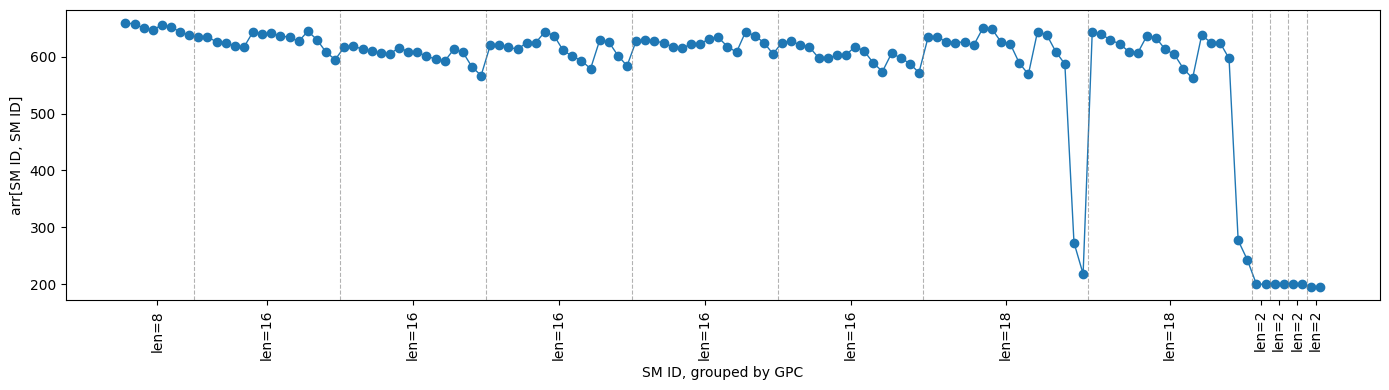

In [71]:
import matplotlib.pyplot as plt

sm_order = np.array([sm_id for sms in gpcs.values() for sm_id in sms])
gpc_boundaries = np.cumsum([len(sms) for sms in gpcs.values()])
gpc_starts = np.concatenate(([0], gpc_boundaries[:-1]))
xtick_positions = (gpc_starts + gpc_boundaries - 1) / 2
xtick_labels = [f"len={len(sms)}" for sms in gpcs.values()]

x = np.arange(len(sm_order))
y = arr[sm_order, sm_order]

plt.figure(figsize=(14, 4))
plt.plot(x, y, marker="o", linewidth=1)

plt.xticks(xtick_positions, xtick_labels, rotation=90)
plt.xlabel("SM ID, grouped by GPC")
plt.ylabel("arr[SM ID, SM ID]")

for boundary in gpc_boundaries[:-1]:
    plt.axvline(boundary - 0.5, color="gray", linestyle="--", linewidth=0.8, alpha=0.6)

plt.tight_layout()
plt.show()

In [72]:
for sm_id in range(0, arr.shape[0], 2):
    tpc_sm0_count = arr[sm_id, sm_id]
    tpc_sm1_count = arr[sm_id + 1, sm_id + 1]

    prob_sm0_with_sm1 = arr[sm_id, sm_id + 1] / tpc_sm0_count if tpc_sm0_count > 0 else 0
    prob_sm1_with_sm0 = arr[sm_id + 1, sm_id] / tpc_sm1_count if tpc_sm1_count > 0 else 0

    print(f"TPC {sm_id//2}")
    print(f"  SM {sm_id} with SM {sm_id + 1}: {prob_sm0_with_sm1*100:.2f}%")
    print(f"  SM {sm_id + 1} with SM {sm_id}: {prob_sm1_with_sm0*100:.2f}%")


TPC 0
  SM 0 with SM 1: 96.81%
  SM 1 with SM 0: 96.96%
TPC 1
  SM 2 with SM 3: 91.34%
  SM 3 with SM 2: 91.34%
TPC 2
  SM 4 with SM 5: 91.57%
  SM 5 with SM 4: 91.28%
TPC 3
  SM 6 with SM 7: 92.74%
  SM 7 with SM 6: 92.74%
TPC 4
  SM 8 with SM 9: 92.99%
  SM 9 with SM 8: 92.85%
TPC 5
  SM 10 with SM 11: 94.08%
  SM 11 with SM 10: 93.78%
TPC 6
  SM 12 with SM 13: 88.64%
  SM 13 with SM 12: 88.50%
TPC 7
  SM 14 with SM 15: 87.87%
  SM 15 with SM 14: 88.28%
TPC 8
  SM 16 with SM 17: 95.23%
  SM 17 with SM 16: 95.67%
TPC 9
  SM 18 with SM 19: 92.17%
  SM 19 with SM 18: 92.32%
TPC 10
  SM 20 with SM 21: 92.66%
  SM 21 with SM 20: 93.11%
TPC 11
  SM 22 with SM 23: 89.95%
  SM 23 with SM 22: 90.54%
TPC 12
  SM 24 with SM 25: 90.27%
  SM 25 with SM 24: 90.56%
TPC 13
  SM 26 with SM 27: 90.98%
  SM 27 with SM 26: 91.57%
TPC 14
  SM 28 with SM 29: 89.94%
  SM 29 with SM 28: 90.08%
TPC 15
  SM 30 with SM 31: 89.19%
  SM 31 with SM 30: 90.05%
TPC 16
  SM 32 with SM 33: 97.26%
  SM 33 with SM 32: 